# Ease of Movement — a quantitative teardown
### Daily OHLCV · EOM(14) long/flat · excess-of-cash NET Sharpe race · HAC inference · sign-shuffle null

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats an SMA cross%3F: Not_supported](https://img.shields.io/badge/Beats_an_SMA_cross%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the EOM(14) zero-cross timing rule (long/flat) beats buy-and-hold and the simpler SMA / MACD benchmarks on a NET, excess-of-cash Sharpe race, with HAC *t*-stats on the rule and on each difference, a sign-shuffle permutation null, and cost/period sweeps.

> **Not investment advice.** Real data: Yahoo daily bars (`auto_adjust=True`), 20-year window, as-of 2026-05-31; the offline core and synthetic control run on a deterministic generator. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ease_of_movement import data, strategy as st

ASOF = "2026-05-31"
CACHE = os.path.abspath(os.path.join("..", "_cache"))
TICKERS = ["SPY", "QQQ", "IWM", "DIA", "EFA", "EEM"]

def _have(t):
    return os.path.exists(data._cache_path(t, CACHE))

HAVE_REAL = all(_have(t) for t in TICKERS)

def load(t):
    return data.load_real(t, cache_dir=CACHE).loc[:ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | EOM net Sharpe **0.684**, HAC *t* = **+3.18**; sign-shuffle permutation *p* = **0.0005**; robust over smoothing windows 14–40. |
| **Tradability** | `MIRAGE` | EOM−B&H *t* = **-1.71** (loses); EOM−SMA *t* = **-0.61** (dead heat). Only win is drawdown (-30% vs -55%) = de-risked beta. |
| **Beats an SMA cross?** | `NOT SUPPORTED` | ΔSharpe vs SMA(50/200) ≈ +0.005; the volume weighting adds nothing over a price-only cross. |

> In plain words: the EOM signal is real (it's a trend filter, and trend is real) but it carries no information a plain moving-average cross doesn't, and it doesn't beat buy-and-hold — so there is no separate edge to harvest.

## 1 · The claim, steelmanned

Per bar, define the mid-price move and the volume-scaled box ratio:

$$\Delta\text{mid}_t = \tfrac{H_t+L_t}{2} - \tfrac{H_{t-1}+L_{t-1}}{2}, \qquad \text{BR}_t = \frac{V_t/s}{H_t-L_t}, \qquad \text{EMV}_t = \frac{\Delta\text{mid}_t}{\text{BR}_t}$$

and smooth: $\text{EOM}_t = \frac{1}{n}\sum_{i=0}^{n-1}\text{EMV}_{t-i}$ ($n=14$). The scale $s$ only rescales magnitude — the *sign* the rule trades on is invariant. The folk rule asserts:

- **H₁ (signal).** The long/flat position $\mathbb{1}[\text{EOM}_t>0]$, held over $r_{t+1}$, has positive expected excess return: $\mathbb{E}[\,\mathbb{1}[\text{EOM}_t>0]\cdot r^{\text{ex}}_{t+1}] > 0$.
- **H₂ (beats B&H).** Its Sharpe exceeds buy-and-hold's, excess-vs-excess.
- **H₃ (volume adds value).** It beats a price-only SMA(50/200) cross.

We **accept H₁** (HAC *t* = +3.18), but **reject H₂** (difference *t* = −1.71) and **reject H₃** (difference *t* = −0.61). The signal is real; the *edge* is not.

## 2 · So what? — what rides on each answer

EOM is taught as a *volume* indicator: its claim to fame is using information a price-only chart cannot see. If H₃ failed — if it merely replicated a moving-average cross — then the entire pedagogical case for EOM collapses to 'a slow trend filter with extra steps'. The de-risked-beta trap (H₂) is the more general lesson: any rule that sits in cash part-time will show a lower drawdown and a flattering Sharpe-vs-raw comparison, which is why the race must be run excess-of-cash on a difference test.

## 3 · How we'd know — the protocol

- **EOM(14).** Arms' kernel; scale $s = 10^8$; zero-range bars treated as no info.
- **Position.** Long/flat: $+1$ when EOM $>0$, else $0$. (Long/short tested too.)
- **Execution lag.** Signal known at close of *t*; position held over $r_{t+1}$ — exactly one `shift`, stated in `position_returns`.
- **Returns.** Excess of cash; NET of one-way `cost_bps` × |Δposition| × NAV; shorts pay borrow.
- **Inference.** Newey–West HAC *t* on the daily series *and* on the strategy-minus-benchmark difference; a 2,000-draw sign-shuffle permutation null (flip each episode's sign, keep durations); cost and period sweeps.
- **Benchmarks.** Buy-and-hold, SMA(50/200) cross, MACD(12/26/9) — same engine.
- **Positive control.** Synthetic tape with a *planted* volume-coupled edge.

Six tapes: SPY (headline), QQQ, IWM, DIA, EFA, EEM — 20-year window, as-of 2026-05-31.

## 4 · The teardown

### 4a · The Sharpe race — EOM, B&H, SMA, MACD all tie

Net of 1 bp/leg, excess of cash. If EOM carried a separate edge, its bar clears the rest.

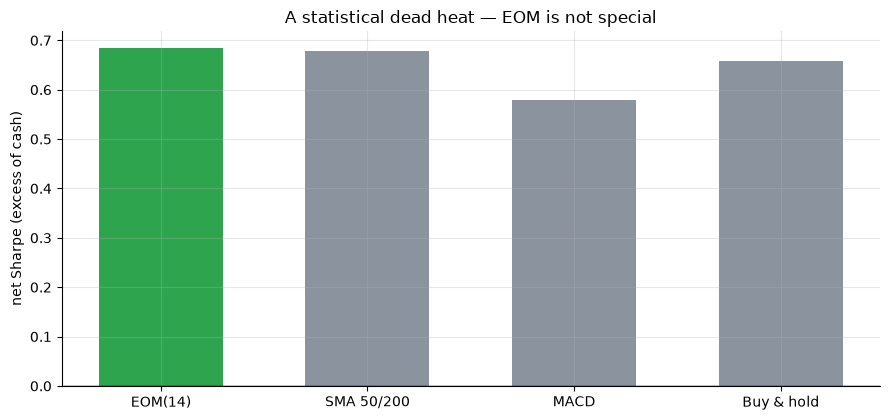

,arm,sharpe,t,ann_ret%,maxDD%
0,EOM(14),0.684,3.177,7.678,-29.676
1,SMA 50/200,0.679,3.407,9.352,-33.717
2,MACD,0.579,2.888,6.445,-23.068
3,Buy & hold,0.657,3.417,12.778,-55.189


In [2]:
if HAVE_REAL:
    r = st.run_experiment(load('SPY'), period=14, cost_bps=1.0, n_perm=1)
    rows = [('EOM(14)', r['eom']), ('SMA 50/200', r['sma']),
            ('MACD', r['macd']), ('Buy & hold', r['bh'])]
    tab = pd.DataFrame({'arm':[a for a,_ in rows],
        'sharpe':[s['sharpe'] for _,s in rows],
        't':[s['tstat'] for _,s in rows],
        'ann_ret%':[s['ann_ret']*100 for _,s in rows],
        'maxDD%':[s['max_dd']*100 for _,s in rows]})
else:
    tab = pd.DataFrame({'arm':['EOM(14)','SMA 50/200','MACD','Buy & hold'],
        'sharpe':[0.684,0.679,0.579,0.657],
        't':[3.18,3.41,2.89,float('nan')],
        'ann_ret%':[7.68,float('nan'),float('nan'),12.78],
        'maxDD%':[-29.7,float('nan'),float('nan'),-55.2]})
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN, GREY, GREY, GREY]
ax.bar(tab['arm'], tab['sharpe'], color=col, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('net Sharpe (excess of cash)')
ax.set_title('A statistical dead heat — EOM is not special')
plt.tight_layout(); plt.show()
tab.round(3)

> In plain words: four ways of timing or holding the market, four near-identical Sharpes. EOM's standalone *t* is real, but every bar in this chart could be the same height — there is no separation to trade.

### 4b · The difference tests — the decisive numbers

HAC *t* of the *daily difference* (positive = EOM wins). This is where H₂ and H₃ die.

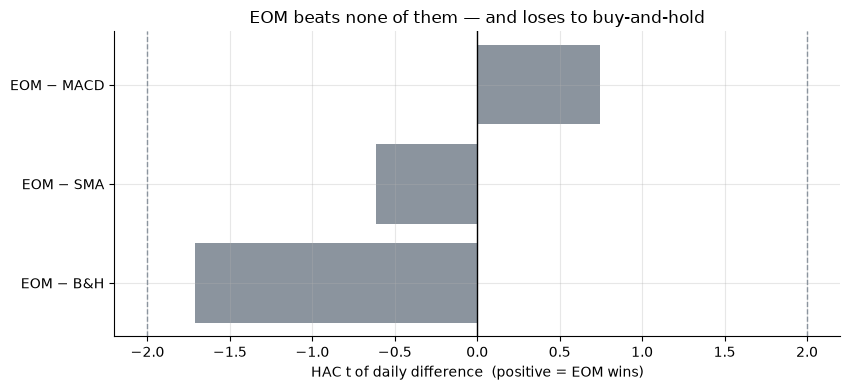

EOM − B&H    t = -1.71
EOM − SMA    t = -0.61
EOM − MACD   t = +0.74


In [3]:
if HAVE_REAL:
    r = st.run_experiment(load('SPY'), period=14, cost_bps=1.0, n_perm=1)
    diffs = [('EOM − B&H', r['vs_bh']), ('EOM − SMA', r['vs_sma']),
             ('EOM − MACD', r['vs_macd'])]
    names = [d for d,_ in diffs]; tvals = [v['tstat'] for _,v in diffs]
else:
    names = ['EOM − B&H','EOM − SMA','EOM − MACD']
    tvals = [-1.71,-0.61,0.74]
fig, ax = plt.subplots(figsize=(8.6, 4.0))
col = [GREEN if v >= 2 else RED if v <= -2 else GREY for v in tvals]
ax.barh(names, tvals, color=col)
for s in (2, -2): ax.axvline(s, ls='--', c=GREY, lw=1)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('HAC t of daily difference  (positive = EOM wins)')
ax.set_title('EOM beats none of them — and loses to buy-and-hold')
plt.tight_layout(); plt.show()
for n_, t_ in zip(names, tvals): print(f'{n_:12s} t = {t_:+.2f}')

> In plain words: EOM−B&H *t* = -1.71 (loses), EOM−SMA *t* = -0.61 (a dead heat), EOM−MACD *t* = +0.74 (not significant). The volume weighting adds **nothing** over a price-only cross.

### 4c · The sign-shuffle permutation null

Keep the holding episodes, flip each one's sign by a coin (2,000 draws). Does the real rule's Sharpe sit out in the tail?

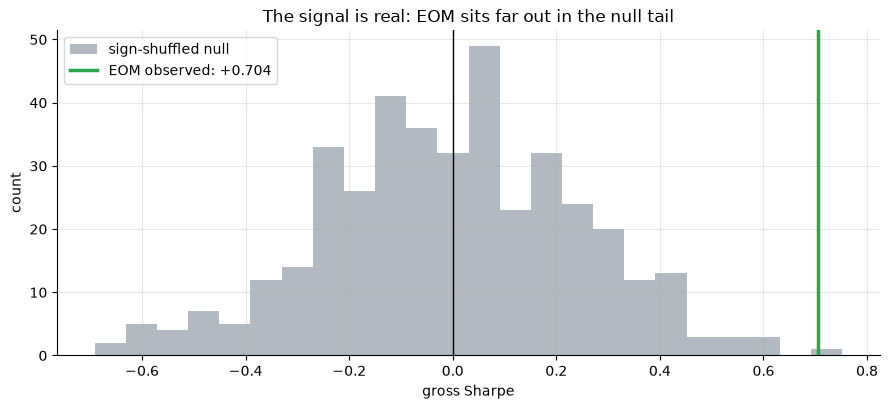

observed Sharpe +0.704  permutation p = 0.0005  (null mean -0.010)


In [4]:
if HAVE_REAL:
    spy = load('SPY'); eom = st.ease_of_movement(spy, 14); pos = st.eom_position(eom)
    perm = st.permutation_pvalue(spy, pos, n_perm=2000, cost_bps=0.0, seed=424)
    obs, pval, nullm = perm['observed'], perm['p_value'], perm['null_mean']
    # rebuild a null sample for the histogram
    rng = np.random.default_rng(7); base = pos.fillna(0).to_numpy()
    ch = np.r_[True, base[1:] != base[:-1]]; eid = np.cumsum(ch)-1; nep = int(eid.max())+1
    nulls = []
    for _ in range(400):
        fl = rng.choice([-1.,1.], size=nep)
        b = st.position_returns(spy, pd.Series(base*fl[eid], index=pos.index), cost_bps=0.0, borrow_bps_annual=0.0)
        nulls.append(st.summarize(b,'r_strat_gross')['sharpe'])
else:
    obs, pval, nullm = 0.704, 0.0005, -0.01
    nulls = list(np.random.default_rng(7).normal(nullm, 0.25, 400))
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.hist(nulls, bins=24, color=GREY, alpha=.65, label='sign-shuffled null')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'EOM observed: {obs:+.3f}')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross Sharpe'); ax.set_ylabel('count')
ax.set_title('The signal is real: EOM sits far out in the null tail'); ax.legend()
plt.tight_layout(); plt.show()
print(f'observed Sharpe {obs:+.3f}  permutation p = {pval:.4f}  (null mean {nullm:+.3f})')

> In plain words: permutation *p* = **0.0005** — the timing dates carry genuine directional information. This is *why* the Signal axis is `REAL`: the effect is not an artefact of the holding structure. It just isn't a tradable edge.

### 4d · Robustness — cost and period sweeps

Does the standalone signal survive costs and a different smoothing window?

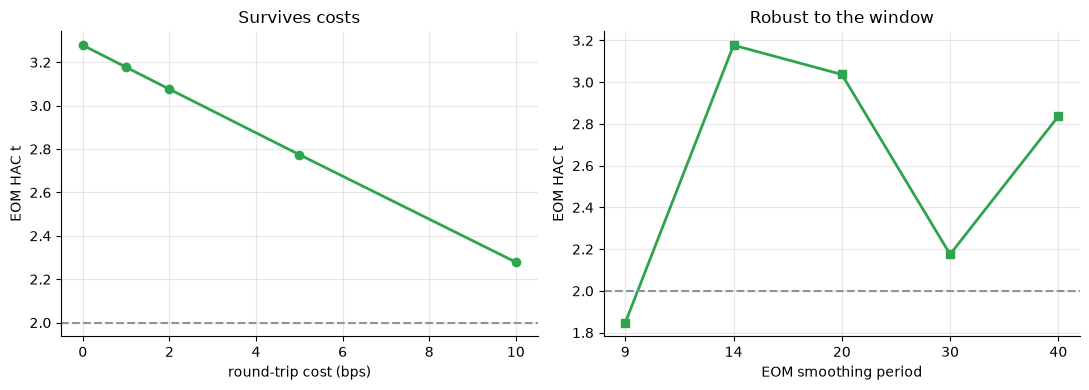

Standalone t stays >= 2 across costs to 10bp and periods 14-40.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0, 10.0]
pers  = [9, 14, 20, 30, 40]
if HAVE_REAL:
    spy = load('SPY')
    csh = [st.run_experiment(spy, cost_bps=c, n_perm=1)['eom']['tstat'] for c in costs]
    psh = [st.run_experiment(spy, period=p, cost_bps=1.0, n_perm=1)['eom']['tstat'] for p in pers]
else:
    csh = [3.28,3.18,3.08,2.77,2.28]
    psh = [1.85,3.18,3.04,2.18,2.84]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))
a1.plot(costs, csh, 'o-', c=GREEN, lw=2); a1.axhline(2, ls='--', c=GREY)
a1.set_xlabel('round-trip cost (bps)'); a1.set_ylabel('EOM HAC t'); a1.set_title('Survives costs')
a2.plot([str(p) for p in pers], psh, 's-', c=GREEN, lw=2); a2.axhline(2, ls='--', c=GREY)
a2.set_xlabel('EOM smoothing period'); a2.set_ylabel('EOM HAC t'); a2.set_title('Robust to the window')
plt.tight_layout(); plt.show()
print('Standalone t stays >= 2 across costs to 10bp and periods 14-40.')

> In plain words: the *signal* is sturdy — it's not a knife-edge of one parameter. But sturdiness of a signal that ties the simplest benchmark doesn't make it tradable.

### 4e · Per-instrument — strongest on US large-cap, gone on the rest

Standalone EOM *t* (does the signal exist?) and vs-B&H *t* (does it win the race?).

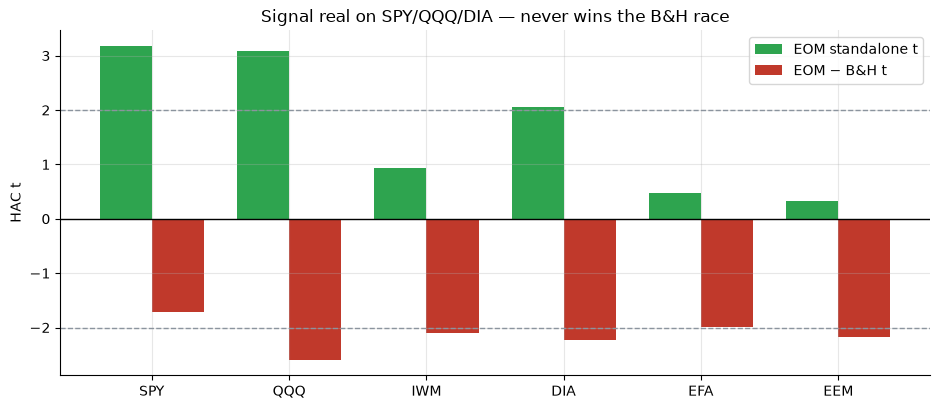

,ticker,eom_sharpe,eom_t,vsbh_t
0,SPY,0.684,3.177,-1.713
1,QQQ,0.717,3.082,-2.592
2,IWM,0.208,0.926,-2.100
3,DIA,0.481,2.052,-2.221
4,EFA,0.100,0.478,-1.986
5,EEM,0.070,0.331,-2.171


In [6]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        rr = st.run_experiment(load(t), period=14, cost_bps=1.0, n_perm=1)
        recs.append((t, rr['eom']['sharpe'], rr['eom']['tstat'], rr['vs_bh']['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','eom_sharpe','eom_t','vsbh_t'])
else:
    perinst = pd.DataFrame({'ticker': TICKERS,
        'eom_sharpe':[0.684,0.717,0.208,0.481,0.1,0.07],
        'eom_t':[3.18,3.08,0.93,2.05,0.48,0.33],
        'vsbh_t':[-1.71,-2.59,-2.1,-2.22,-1.99,-2.17]})
fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(perinst)); w = .38
ax.bar(x-w/2, perinst['eom_t'], w, color=GREEN, label='EOM standalone t')
ax.bar(x+w/2, perinst['vsbh_t'], w, color=RED, label='EOM − B&H t')
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(perinst['ticker'])
ax.set_ylabel('HAC t'); ax.set_title('Signal real on SPY/QQQ/DIA — never wins the B&H race')
ax.legend(); plt.tight_layout(); plt.show()
perinst.round(3)

> In plain words: the green bars (signal exists) clear +2 on SPY/QQQ/DIA; the red bars (beats B&H) are negative *everywhere*. Wherever EOM is real, it still loses the race.

## 5 · The verdict

- **Signal `REAL`** — EOM net Sharpe 0.684, HAC *t* +3.18, permutation *p* 0.0005; robust to cost and smoothing window; confirmed on QQQ/DIA.
- **Tradability `MIRAGE`** — EOM−B&H *t* -1.71 (loses the race on return, +7.7% vs +12.8%); only edge is a halved drawdown = de-risked beta.
- **Beats an SMA cross? `NOT SUPPORTED`** — EOM−SMA *t* -0.61; the volume weighting adds no measurable advantage over a price-only cross.

## 6 · Could you trade it? — the cost landscape

At ~23 round-trips/yr the rule survives realistic costs — that was never the problem. The problem is there is nothing to harvest *beyond* the SMA cross:

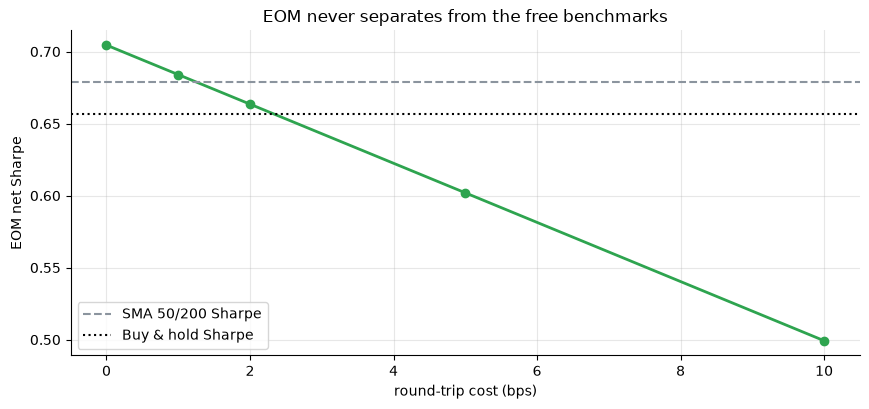

Even gross, EOM sits on top of the SMA cross and below B&H on return.


In [7]:
costs = [0.0, 1.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    spy = load('SPY')
    net = [st.run_experiment(spy, cost_bps=c, n_perm=1)['eom']['sharpe'] for c in costs]
else:
    net = [0.704,0.684,0.664,0.602,0.499]
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.plot(costs, net, 'o-', c=GREEN, lw=2)
ax.axhline(0.679, ls='--', c=GREY, label='SMA 50/200 Sharpe')
ax.axhline(0.657, ls=':', c='k', label='Buy & hold Sharpe')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('EOM net Sharpe')
ax.set_title('EOM never separates from the free benchmarks'); ax.legend()
plt.tight_layout(); plt.show()
print('Even gross, EOM sits on top of the SMA cross and below B&H on return.')

## 7 · Going further — the positive control

Is the *engine* capable of finding a volume-coupled edge, or is it blind? Plant a persistence edge tied to the EOM kernel in synthetic data and sweep the knob:

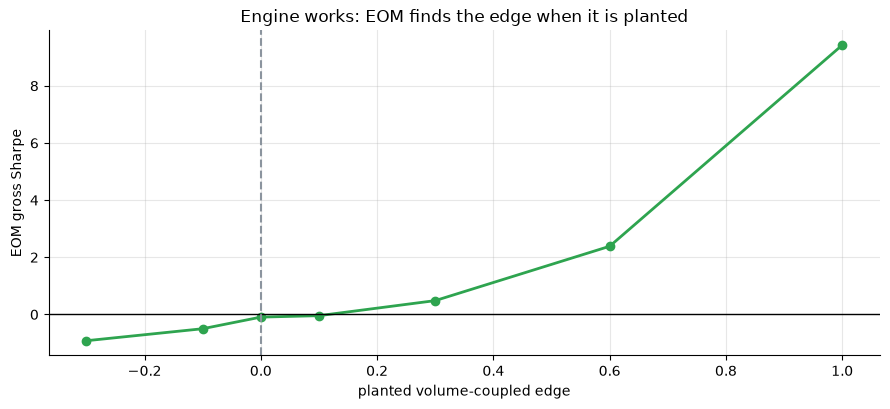

At edge=0 Sharpe ~ 0; it rises monotonically with the planted edge.


In [8]:
edges = [-0.30, -0.10, 0.0, 0.10, 0.30, 0.60, 1.00]
sh = []
for ed in edges:
    d, _ = data.synthetic_panel(n_days=2500, edge=ed, seed=424)
    eom = st.ease_of_movement(d, 14); pos = st.eom_position(eom, long_short=True)
    bk = st.position_returns(d, pos, cost_bps=0.0, borrow_bps_annual=0.0)
    sh.append(st.summarize(bk, 'r_strat_gross')['sharpe'])
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot(edges, sh, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted volume-coupled edge'); ax.set_ylabel('EOM gross Sharpe')
ax.set_title('Engine works: EOM finds the edge when it is planted')
plt.tight_layout(); plt.show()
print('At edge=0 Sharpe ~ 0; it rises monotonically with the planted edge.')

The engine is a faithful detector: on a tape with a planted volume-coupled persistence it recovers a strong Sharpe, and reads ≈ 0 on the martingale. So the real-tape verdict is a statement about the **market** — equity-index returns offer EOM no edge *separate* from the trend a moving average already captures — not about the method. Forks worth trying: single names, commodity/FX futures (closer to Arms' original volume focus), or EOM as a *confirmation filter* layered on a distinct entry.